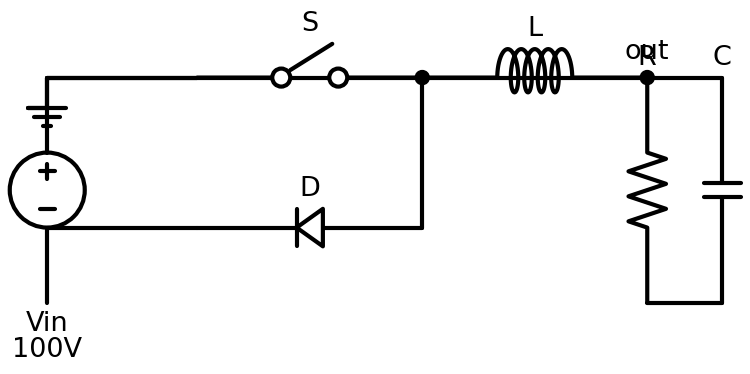

In [13]:
import schemdraw
import schemdraw.elements as elm
import matplotlib.pyplot as plt
from IPython.display import Image, display

with schemdraw.Drawing(show=False) as d:
    d.config(fontsize=13)
    Vin = d.add(elm.SourceV().up().label('Vin\n100V', loc='left'))
    d.add(elm.Line().right(2))
    d.add(elm.Switch().right().label('S', loc='top'))
    sw = d.add(elm.Dot())
    d.add(elm.Inductor2().right().label('L', loc='top'))
    d.add(elm.Dot().label('out', loc='top'))
    d.add(elm.Line().right(1))
    d.add(elm.Capacitor().down().label('C', loc='right'))
    d.add(elm.Line().left(1))
    d.add(elm.Resistor().up().label('R', loc='right'))
    d.add(elm.Line().left().tox(Vin.start))
    d.add(elm.Ground())
    d.add(elm.Line().at(sw.end).down(2))
    d.add(elm.Diode().left().label('D', loc='top'))
    d.add(elm.Line().left().tox(Vin.start))
    d.save('buck_ccm_1_fig.png', dpi=150)

display(Image('buck_ccm_1_fig.png', width=320))

In [14]:
%pycat buck_ccm_orig.in

Buck Converter CCM
Vin in 0 DC $Vin
Vpwm gate 0 PULSE(0 5 0 1n 1n $TON $T)
S1 in sw gate 0 SWMOD
D1 0 sw DMOD
L1 sw out $L IC=0
C1 out 0 $C IC=0
RL out 0 $R
.MODEL SWMOD SW(Ron=0.01 Roff=1MEG Vt=2.5)
.MODEL DMOD D(Is=1n N=1 Rs=0.01)
.TRAN $TSTEP $TEND UIC
.SAVE $SAVE_VARS
.END


In [18]:
import ngspice_calc as calc

s_Vin = '100'
s_L = '0.6e-3'
s_C = '50e-6'
s_R = '2.5'
s_D = '0.4'
s_f_hz = '10e3'

D = float(s_D)
f_hz = float(s_f_hz)
T = 1.0 / f_hz
Ton = D * T
Tstep = T / 500
Tend = 50*T

l = [
    ('$Vin', s_Vin),
    ('$L', s_L),
    ('$C', s_C),
    ('$R', s_R),
    ('$TON', f'{Ton:.10f}'),
    ('$T', f'{T:.10f}'),
    ('$TSTEP', f'{Tstep:.10f}'),
    ('$TEND', f'{Tend:.6f}'),
    ('$SAVE_VARS', f'v(out) v(sw) i(l1) i(vin)')
]


calc.replace_strings_1('buck_ccm_orig.in', 'buck_ccm.in', l)
print("buck_ccm.in is ready for use")

buck_ccm.in is ready for use


In [19]:
calc.run_ngspice('buck_ccm.in')


Note: No compatibility mode selected!


Circuit: buck converter ccm

binary raw file "buck_ccm.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 5  
Operating point simulation skipped by 'uic',
  now using transient initial conditions.

No. of Data Rows : 27484

Total analysis time (seconds) = 0.160668

Total elapsed time (seconds) = 0.166 

Total DRAM available = 15614.746 MB.
DRAM currently available = 3995.508 MB.
Maximum ngspice program size =   21.406 MB.
Current ngspice program size =   12.555 MB.

Shared ngspice pages =   10.777 MB.
Text (code) pages =    7.105 MB.
Stack = 0 bytes.
Library pages =    1.879 MB.




'buck_ccm.raw'

In [20]:
import numpy as np

s = calc.slv('buck_ccm.in')
print("Variables: ", s.variables())

Variables:  ['time', 'v(out)', 'v(sw)', 'i(l1)', 'i(vin)']


In [21]:
t1 = s.get_array('time')
IL = s.get_array('i(l1)')
Vout = s.get_array('v(out)')
Vsw = s.get_array('v(sw)')
I_vin = s.get_array('i(vin)')

R = float(s_R)

IS = -I_vin
ID = np.where(Vsw<1.0, IL, 0.0)
I_load = Vout / R
IC = IL - I_load

t_start_ss = t1[-1] - 2 * T

l_IL    = calc.avg_rms(t1, IL,    t_start=t_start_ss)
l_IS    = calc.avg_rms(t1, IS,    t_start=t_start_ss)
l_ID    = calc.avg_rms(t1, ID,    t_start=t_start_ss)
l_IC    = calc.avg_rms(t1, IC,    t_start=t_start_ss)
l_v_out = calc.avg_rms(t1, Vout,  t_start=t_start_ss)

IL_min, IL_max = calc.min_max(t1, IL,   t_start=t_start_ss)
VC_min, VC_max = calc.min_max(t1, Vout, t_start=t_start_ss)

IL_ptop = IL_max - IL_min
VC_ptop = VC_max - VC_min

print(f'average output voltage  : {l_v_out[0]:11.4E}')
print(f'average inductor current: {l_IL[0]:11.4E}')
print(f'average switch current  : {l_IS[0]:11.4E}')
print()
print(f'IL_ptop : {IL_ptop:11.4E}')
print(f'IL_peak : {IL_max:11.4E}')
print(f'VC_ptop : {VC_ptop:11.4E}')
print()
print(f'IL_rms  : {l_IL[1]:11.4E}')
print(f'IS_rms  : {l_IS[1]:11.4E}')
print(f'ID_rms  : {l_ID[1]:11.4E}')
print(f'IC_rms  : {l_IC[1]:11.4E}')
print(f'Vout_avg: {l_v_out[0]:11.4E}')

average output voltage  :  0.0000E+00
average inductor current:  0.0000E+00
average switch current  :  0.0000E+00

IL_ptop :  0.0000E+00
IL_peak :  0.0000E+00
VC_ptop :  0.0000E+00

IL_rms  :  0.0000E+00
IS_rms  :  0.0000E+00
ID_rms  :  0.0000E+00
IC_rms  :  0.0000E+00
Vout_avg:  0.0000E+00
